## **<center>From Experiment to Decision</center>**
## **<center> Statistical Analysis of Conversion Rates Using A/B Testing and Z-Test</center>**

## 1. Executive Summary

This project evaluates whether a redesigned webpage improves user conversion compared to the existing version. An A/B test compared a control group (current page) against a treatment group (new page).

Results show the new page does not improve conversions. The treatment group produced a slightly lower conversion rate than the control group, and statistical testing confirms this difference is not statistically significant. There is no evidence that the redesign drives better performance.

From a business standpoint, the observed negative uplift suggests a risk of decreased conversions and revenue if the new page were rolled out. Based on both statistical evidence and practical business impact, the new page should not be launched.

## Introduction

A/B testing is a core tool in data-driven product decisions. This project analyzes whether a redesigned webpage leads to higher user conversion, combining statistical testing with practical business interpretation.

## 2. Problem Definition & Context


At its core, this project is trying to answer a very practical product question: *does a new version of a webpage actually perform better than the current one?* This is a common scenario in digital products, especially in e-commerce, where even small improvements can translate into meaningful revenue gains.

In this experiment, we’re comparing two versions of a webpage:

* The **old page** (what users currently see)
* The **new page** (a redesigned version)

Users are randomly assigned to one of these two groups:

* **Control group** sees the old page
* **Treatment group** sees the new page

The *page* column confirms which version was shown, and the *converted* column tells us whether the user completed the desired action. For example, making a purchase or signing up.

---

### What counts as success?

Success in this experiment is defined by conversion. In simple terms:

* A user who converts *converted* = 1
* A user who does not *converted* = 0


---

### Why this experiment matters?

From a business perspective, launching a new page isn’t just about aesthetics but it’s about performance. A redesign might look better, but if it confuses users or adds friction, it could actually hurt conversions. Therefore, instead of relying on intuition or design preference, we use an A/B test to make a data-driven decision:

* Does the new page genuinely improve user behavior?
* Or is any observed difference just due to random chance?

---

### Hypotheses

To answer this, we formalize the problem using statistical hypotheses.

* **Null hypothesis (H₀):**
  The new page does not perform better than the old page. The conversion rate of new page would be equal or less than old page.

* **Alternative hypothesis (H₁):**
  The new page performs better than the old page. The conversion rate of new page would be greater than old page.

---

### Intuition behind the hypotheses

We think of the null hypothesis as the skeptical default. We assume that the new page does not provide an improvement unless the data gives us strong enough evidence to believe otherwise.

The goal of this analysis is not to prove the new page is better outright, but rather to test whether we have enough statistical evidence to reject the null hypothesis.

If we do, then we would have support for launching the new page. If we don’t then would stick with the old page or run further experiments.



## Methodology


**1. Experiment Design**

An A/B test was conducted to evaluate the performance of a new webpage (treatment group) against the existing webpage (control group). Users were randomly assigned to either group to ensure unbiased comparison and minimize selection bias.

**2. Evaluation Metric**

The primary metric used to assess performance was the conversion rate, defined as the proportion of users who completed the desired action (e.g., sign-up or purchase) out of the total number of users in each group.

**3. Hypotheses**

The experiment was designed to test whether the new webpage improves conversion rates:

* Null Hypothesis (H₀): The conversion rate of the new page is less than or equal to that of the old page.
* Alternative Hypothesis (H₁): The conversion rate of the new page is greater than that of the old page.

**4. Statistical Test**

A two-proportion Z-test was used to compare the conversion rates between the control and treatment groups. This test is appropriate due to the binary nature of the outcome (conversion vs no conversion) and the sufficiently large sample size.

The validity of the z-test relies on independence of observations and sufficiently large sample sizes, both of which are addressed through data cleaning and dataset size.

**5. Significance Level**

A significance level of α = 0.05 was used.
If the p-value is less than α, the null hypothesis is rejected, indicating a statistically significant difference between the two groups.

## 3. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

ab_test = pd.read_csv('ab_test.csv')

## 4. Dataset Description

In [2]:
ab_test.head(5)

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [3]:
rows, col = ab_test.shape
print('---SHAPE OF DATASET---')
print(f"Rows: {rows:9}"); print(f"Columns: {col}");



---SHAPE OF DATASET---
Rows:    294478
Columns: 5


**Dataset Columns Descriptions**

| Column    | Description                            |
| --------- | -------------------------------------- |
| id        | Unique user identifier                 |
| time      | Timestamp of visit                     |
| con_treat | Treatment group (control vs treatment) |
| page      | Old or new page                        |
| converted | 1 = converted, 0 = not                 |

In [4]:
ab_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         294478 non-null  int64 
 1   time       294478 non-null  object
 2   con_treat  294478 non-null  object
 3   page       294478 non-null  object
 4   converted  294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


## 5. Data Cleaning & Validation

In [5]:
summary = pd.DataFrame({'Data Type': ab_test.dtypes, 
                        'Null Value': ab_test.isnull().sum(),
                        'Null %': ab_test.isnull().mean() * 100,
                        'Unique' : ab_test.nunique()
                       }
)
summary

,Data Type,Null Value,Null %,Unique
id,int64,0,0.0,290584
time,object,0,0.0,35993
con_treat,object,0,0.0,2
page,object,0,0.0,2
converted,int64,0,0.0,2


In [6]:
print(f"● There are {ab_test.id.duplicated().sum()} duplicated user IDs in the dataset.")

● There are 3894 duplicated user IDs in the dataset.


In [7]:
(
    ab_test[ab_test['id']
            .duplicated(keep=False)]
            .sort_values('id')
            .head(6)
            )

,id,time,con_treat,page,converted
213114,630052,25:54.1,treatment,old_page,1
230259,630052,16:05.2,treatment,new_page,0
251762,630126,16:00.3,treatment,new_page,0
22513,630126,35:54.8,treatment,old_page,0
11792,630137,59:22.1,control,new_page,0
183371,630137,08:49.9,control,old_page,0


* Generally speaking, in A/B testing, each user should appear only once and should be exposed to only one condition. Dataset shows that a user appears multiple times either they may have been exposed to both variants or recorded multiple interactions. Therefore, this breaks the assumption of independent observations.
* There are two valid options, either removing all duplicated users ID entirely or keep the first occurrance. If we go with first option, it keeps dataset clean and unbiased. If we go with second option, which would be an arbitrary choice and could introduce bias. Because we can’t trust which exposure is valid.

**Remove mismatches**

* In this experiment of A/B test, Control group should only see the old page and Treatment group should only see the new page. However, the dataset shows that there are users who see the wrong page that might be due to technical issues, user tampering, or tracking errors. Therefore, their behavior doesn't reflect the intended experiment and they could bias the results.
* We run boolean filter to keep only the logically consistent rows in the A/B test, where the con_treat assignment matches the page they actually saw.

In [8]:
correct = ((ab_test['con_treat'] == 'control') & (ab_test['page'] == 'old_page')) | \
          ((ab_test['con_treat'] == 'treatment') & (ab_test['page'] == 'new_page'))

ab_test = ab_test[correct]

print(f"Keeping {correct.sum()} out of {len(correct)} rows")
print(f"Removing {(~correct).sum()} invalid rows")


Keeping 290585 out of 294478 rows
Removing 3893 invalid rows


* This filtering step ensures that we only analyze data from users who experienced the experiment as designed and we maintain the integrity of the A/B test analysis.

**Remove duplicate users**

In [9]:
ab_test = ab_test.drop_duplicates(subset='id', keep=False)
print(f"There are {ab_test.id.duplicated().sum()} duplicate user IDs.")

There are 0 duplicate user IDs.


* Firstly, we filtered the dataset to remove all mismatched records where the treatment group did not align with the corresponding page. After ensuring consistency, we removed all the remaining duplicated user entries to maintain the integrity of the experiment.

**Time Column**

The time column contains partial time information (minute:second format) and does not provide sufficient context for temporal analysis. Since it is not required for hypothesis testing, it will be excluded from further analysis.

This is not a limitation for the experiment, as A/B testing relies on randomized group assignment rather than time-based comparisons.

## 6. Exploratory Data Analysis

**Conversion Count**

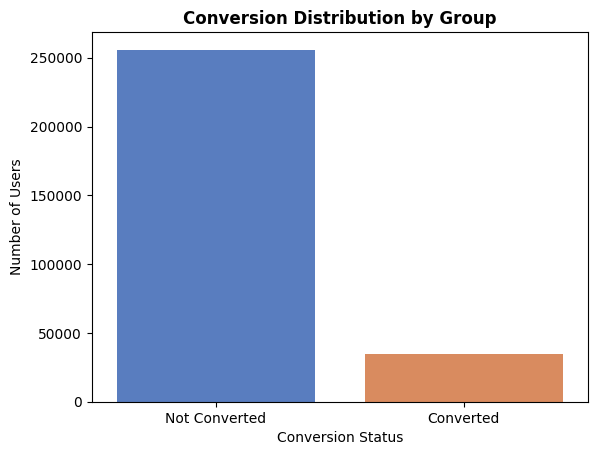

In [10]:
ax = sns.countplot(x=ab_test.converted, 
                   hue=ab_test.converted,
                   palette='muted', 
                   legend=False)

plt.title('Conversion Distribution by Group', 
          fontsize=12, 
          fontweight='bold')
plt.xlabel('Conversion Status', 
           fontsize=10)
plt.ylabel('Number of Users', 
           fontsize=10)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Converted', 'Converted'])

plt.show()


**Conversion Rate**

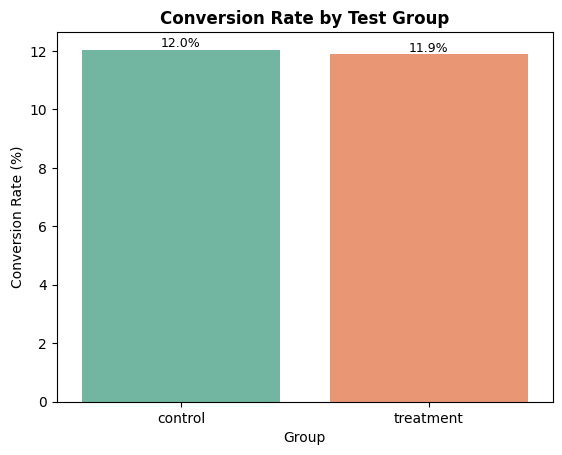

In [ ]:
warnings.filterwarnings("ignore")

con_rate = ab_test.groupby('con_treat')['converted'].mean()*100

ax = sns.barplot(x=con_rate.index, y=con_rate.values,
                 palette="Set2")

ax.set_title('Conversion Rate by Test Group',
             fontsize=12, 
             fontweight='bold')
ax.set_xlabel('Group', 
              fontsize=10)
ax.set_ylabel('Conversion Rate (%)', 
              fontsize=10)


for bar in ax.patches:
    height = bar.get_height()  
    x = bar.get_x() + bar.get_width() / 2
    
    ax.text(x, height, f'{height:.1f}%', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=9)
    
plt.show()


* In the control group, about 12.04% of users converted. It means about 12 out of every 100 users completed the desired action
* In the treatment group, about 11.88% of users converted. It means about 11.9 out of every 100 users completed the desired action

* The bar chart shows a very small difference in conversion rates between the two groups. The control group converts at 12.0%, while the treatment group converts at 11.9%. This suggests that the new variation (treatment) did not improve performance and may even have slightly underperformed compared to the baseline. However, the difference is 0.1 percentage points, which is extremely small and likely not practically meaningful. In an A/B testing context, this result would require a statistical significance check such as a p-value before making conclusions. Most likely, this indicates that the treatment has no meaningful impact on user behavior. 


## 7. Statistical Testing

* Since the comparison is between groups, not across time, the focus is on comparing conversion rates between the control and treatment groups. After computing the observed conversion rates, the initial difference between the two groups provides a preliminary indication of performance. However, this observed difference alone is not sufficient to draw conclusions, as it may be due to random chance.

**Hypothesis**

* To formally evaluate whether the difference is statistically significant, a hypothesis test for proportions (Z-test) will be conducted. This allows us to determine whether the observed difference reflects a real effect or is likely due to chance.

p_control = conversion rate of the control group  
p_treatment = conversion rate of the treatment group  

We define the hypotheses as:

- **Null Hypothesis (H0):** The new variant has no effect on conversion rate. 
  - The new page does not improve the conversion rate compared to the old page.

- **Alternative Hypothesis (H1):** The new variant significantly changes the conversion rate.
  - The new page leads to a higher conversion rate than the old page.

This is a one-sided test, as we are specifically interested in whether the treatment performs better, not just differently.

**Method**

* The z-test is used because the primary metric in this experiment is binary—a user either converts or does not. This test directly compares conversion rates between two independent groups (control vs treatment). The reason for choosing the z-test is that the outcome variable is categorical (converted vs not converted), it compares proportions between two independent samples, and the sample size is large enough to justify a normal approximation.

* Before applying the z-test, we verify that sample sizes are sufficiently large and observations are independent, ensuring the validity of the normal approximation.

In [12]:
control = ab_test[ab_test['con_treat'] == 'control']
treatment = ab_test[ab_test['con_treat'] == 'treatment']

conv_control = control['converted'].sum()
conv_treatment = treatment['converted'].sum()

n_control = control.shape[0]
n_treatment = treatment.shape[0]

In [26]:
conv_control

np.int64(17489)

In [13]:
from statsmodels.stats.proportion import proportions_ztest

conversions = [conv_treatment, conv_control]
samples = [n_treatment, n_control]

z_stat, p_value = proportions_ztest(conversions, samples, alternative='larger')


summary = pd.DataFrame({
    "Statistic": ["Z-statistic", "P-value"],
    "Value": [f"{z_stat:.4f}", f"{p_value:.4f}"]
})
summary


,Statistic,Value
0,Z-statistic,-1.3102
1,P-value,0.9049


**Interpretation**

* The Z-statistic produces -1.3102. This negative Z-statistic suggests that the new page actually performed slightly worse than the old page. Therefore, but importantly, the difference is not statistically significant.
* The p-value is very high (0.9049), which tells us that the observed difference in conversion rates is very likely due to random chance rather than a real effect.
* Overall, even though we tested a new version of the page, users did not convert at a higher rate in any meaningful way. In fact, the results slightly favor the old page — but not strongly enough to draw a firm conclusion.
* Failing to reject the null hypothesis does not mean that the old page is better or there is no difference between them at all. It basically means that we do not have enough evidence to make a conclusion that the new page is better.

* From a decision-making perspective, there is no statistical evidence that the new page improves conversions. Therefore, launching the new page would be risky, as it may provide no benefit even slightly reduce performance. As a result of that, a safe and data-driven decision would be to not launch the new page based on this experiment.

**Effect Size**


In [ ]:
# Group statistics
summary = ab_test.groupby('con_treat')['converted'].agg(['mean', 'count'])

p_control = summary.loc['control', 'mean']
p_treatment = summary.loc['treatment', 'mean']

n_control = summary.loc['control', 'count']
n_treatment = summary.loc['treatment', 'count']

# Effect size
abs_diff = p_treatment - p_control
rel_uplift = abs_diff / p_control

# Standard error
se = np.sqrt(
    (p_control * (1 - p_control)) / n_control +
    (p_treatment * (1 - p_treatment)) / n_treatment
)

# CI
z = 1.96
ci_lower = abs_diff - z * se
ci_upper = abs_diff + z * se


result_effect_size = pd.DataFrame({
    "Metric": ["Absolute Difference", "Relative Uplift", "95% CI"],
    "Value": [
        f"{abs_diff*100:.3f}%",
        f"{rel_uplift*100:.3f}%",
        f"[{ci_lower*100:.3f}%, {ci_upper*100:.3f}%]"
    ]
})

result_effect_size

,Metric,Value
0,Absolute Difference,-0.158%
1,Relative Uplift,-1.310%
2,95% CI,"[-0.394%, 0.078%]"


* The treatment group shows a decrease in conversion rate compared to the control group, with an absolute difference of −0.158 percentage points and a relative change of −1.31%.

* The 95% confidence interval for the difference ranges from −0.394% to 0.078%. Since this interval includes zero, the true effect could be either slightly negative or slightly positive.

* This indicates that the observed difference is not statistically significant and, more importantly, is small in magnitude. Therefore, there is no strong evidence that the treatment provides a meaningful improvement over the control.

## Practical Significance

In [15]:
p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment

uplift = p_treatment - p_control

print(f"---A/B TEST RESULTS: UPLIFT ASSESSMENT---")
print(f"Control Conversion Rate: {p_control:8.4f}")
print(f"Treatment Conversion Rate: {p_treatment:5.4f}")
print(f"Uplift (absolute): {uplift:16.6f}")

---A/B TEST RESULTS: UPLIFT ASSESSMENT---
Control Conversion Rate:   0.1204
Treatment Conversion Rate: 0.1188
Uplift (absolute):        -0.001577


* The initial comparison shows a slightly lower conversion rate for the treatment group (11.88%) compared to the control group (12.04%), resulting in an absolute difference of -0.16 percentage points.
* While this suggests a small negative observed effect, the difference is minimal and, as shown in the statistical testing, falls within the range of random variation. Therefore, this effect should not be interpreted as a confirmed decrease in performance.

**Practical Impact of Experiment**

In [16]:

import numpy as np

# Simulated Business Impact (Based on Assumptions)
assumed_n_control = 50000       # control users
assumed_n_treatment = 50000       # treatment users 

# --- Business assumptions ---
daily_users = 100000
value_per_conversion = 50

# --- Uplift ---
uplift = p_treatment - p_control

# --- Standard Error ---
se = np.sqrt(p_control*(1-p_control)/assumed_n_control + 
             p_treatment*(1-p_treatment)/assumed_n_treatment)


# --- 95% Confidence Interval ---
ci_low = uplift - 1.96 * se
ci_high = uplift + 1.96 * se

# --- Business Impact ---
expected_revenue = uplift * daily_users * value_per_conversion
ci_rev_low = ci_low * daily_users * value_per_conversion
ci_rev_high = ci_high * daily_users * value_per_conversion

print("---A/B Test Results---")
print(f"Uplift: {uplift*100:.4f}")
print(f"95% CI (uplift): [{ci_low:.4f}, {ci_high:.4f}]")

print("\n---Business Impact---")
print(f"Expected daily impact: ${expected_revenue:,.0f}")
print(f"95% CI: [${ci_rev_low:,.0f}, ${ci_rev_high:,.0f}]")


---A/B Test Results---
Uplift: -0.1577
95% CI (uplift): [-0.0056, 0.0024]

---Business Impact---
Expected daily impact: $-7,887
95% CI: [$-27,999, $12,225]


To evaluate practical significance, the observed uplift in conversion rate was first calculated directly from the dataset. The results show a small negative effect, indicating that the new page performs slightly worse than the old page.

To better understand the real-world implications of this effect, it was translated into business impact using reasonable assumptions about daily user traffic and average revenue per conversion. Under these assumptions, the new page could lead to a loss of approximately 158 conversions per day, corresponding to an estimated daily revenue decrease of around 7,887$.

These estimates assume 100,000 daily users and $50 average revenue per conversion. If actual traffic or revenue differs, the absolute loss would scale proportionally.

While these estimates are based on hypothetical values, they provide a useful approximation of potential business impact and help bridge the gap between statistical results and real-world decision-making. Even a small negative change in conversion rate can result in substantial losses.

Overall, both the statistical analysis and the practical impact assessment consistently indicate that the new page does not provide value. Therefore, there is no evidence to support launching the new page, and the observed negative trend suggests caution.

## Experiment Validity Checks

### Sample Ratio Mismatch

In [17]:
print("---SRM CHECK: ABSOLUTE COUNTS---")

# Shows the raw number of users assigned to control vs treatment
group_counts = ab_test['con_treat'].value_counts()
print(group_counts)


print("\n---SRM CHECK: PROPORTIONS---")
group_props = ab_test['con_treat'].value_counts(normalize=True)
print(group_props)

---SRM CHECK: ABSOLUTE COUNTS---
con_treat
treatment    145309
control      145274
Name: count, dtype: int64

---SRM CHECK: PROPORTIONS---
con_treat
treatment    0.50006
control      0.49994
Name: proportion, dtype: float64


* To verify the integrity of the experiment, a Sample Ratio Mismatch (SRM) check was conducted to ensure that users were evenly distributed between the control and treatment groups.
* The SRM check shows that the control (49.99%) and treatment (50.01%) groups are nearly perfectly balanced, indicating that random assignment worked as expected. The small difference in sample sizes is within normal random variation and does not suggest any bias or allocation issues. Therefore, there is no evidence of a sample ratio mismatch.

**Applying Chi_Squared**

* The chi-square test used to evaluate whether there is an association between page version (control vs treatment) and conversion outcome. The reason for choosing the chi-square test is that both variables are categorical (page type and conversion status), it evaluates independence between two categorical variables, and it provides a distribution-free, non-parametric confirmation of the relationship.

In [ ]:
from scipy.stats import chisquare

# observed counts
observed = group_counts.to_numpy()

# expected counts (50/50 split)
expected = [sum(observed)/2, sum(observed)/2]

chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)


chi2_summary = pd.DataFrame({
    "Statistic": ["Chi-square", "P-value"],
    "Value": [f"{chi_stat:.4f}", f"{p_value:.4f}"]
})
chi2_summary

,Statistic,Value
0,Chi-square,0.0042
1,P-value,0.9482


* A chi-square test was performed to formally assess this distribution, resulting in a p-value of 0.9482. Since this value is significantly higher than the 0.05 threshold, there is no evidence of a sample ratio mismatch. This indicates that the randomization process was properly implemented, and the group assignment can be considered reliable for further analysis.


### Randomization Issues

In [19]:
mismatch = ab_test[
    # Control users should NOT see new_page
    ((ab_test['con_treat'] == 'control') & (ab_test['page'] != 'old_page')) |
    # Treatment users should NOT see old_page
    ((ab_test['con_treat'] == 'treatment') & (ab_test['page'] != 'new_page'))
]

print(f"Mismatched rows: {len(mismatch)}")

# Users should appear exactly once in the experiment data
duplicate_users = ab_test['id'].duplicated().sum()
print(f"Duplicate users: {duplicate_users}")

# Display first 10 rows of duplicated users to understand the issue
# keep=False shows ALL occurrences of duplicated IDs (not just the second+)
ab_test[ab_test['id'].duplicated(keep=False)].sort_values('id').head(10)

Mismatched rows: 0
Duplicate users: 0


,id,time,con_treat,page,converted


* To further validate the integrity of the experiment, checks for randomization issues were conducted by examining mismatched records and duplicate user entries. The results show that there are no mismatched rows between the assigned treatment groups and the corresponding pages, and no duplicate user IDs are present in the dataset. This means each user was consistently exposed to the correct page and appears only once in the dataset. This satisfies the assumptions of proper randomization and independence of observations. As a result, the data can be considered reliable for conducting the A/B test analysis.


## Limitalion

While the analysis provides useful insights, several limitations should be acknowledged. Firstly, the dataset does not include complete or reliable timestamp information. It prevents analysis of temporal effects such as novelty bias or seasonality. As a result, it is not possible to evaluate how user behavior may change over time.

Additionally, the dataset lacks contextual business information such as total daily traffic and revenue per conversion. Therefore, the practical impact analysis relies on assumptions to estimate real-world effects.

Finally, the analysis does not consider user segmentation (e.g., device type, location, or user behavior), which could reveal more nuanced insights. Future work could incorporate these factors to provide a more comprehensive evaluation.

## Conclusion

**Statistical Conclusion**

The A/B test found no statistically significant difference in conversion rates between the control and treatment groups. Both the proportion test and the Chi-Square test confirm that the observed difference is likely due to random variation rather than a true improvement. There is insufficient evidence to conclude that the new page outperforms the existing version.

**Financial / Business Conclusion**

The new page produced a slightly lower conversion rate than the original. Even though the difference is not statistically significant, the direction of impact suggests potential revenue loss if deployed at scale. Given the absence of measurable improvement and the risk of reduced conversions, rolling out the new design is not recommended.

## Next Steps

Even though this experiment doesn’t support rolling out the new page just yet, there are still several ways to learn more and make better decisions moving forward:

**1. Run the Test Longer & Gather More Data**

Let the experiment run a bit longer to collect more data. A larger sample size will give more confidence in the results and help detect smaller but important effects.

**2. Look at Different User Segments**

Break the results down by key groups, such as:

* Device type (mobile vs. desktop)
* Traffic source (organic, paid, referral)
* Geographic location

This can uncover patterns that aren’t visible in the overall results.

**3. Dig Into User Behavior**

Take a closer look at metrics like:

* Click-through rates
* Time on page
* Bounce rates

These can help explain why the new page is underperforming and point to areas for improvement.

**4. Keep Iterating on the Design**

Instead of scrapping the redesign, try refining it. Build improved versions and continue testing — A/B testing works best as an ongoing, iterative process. In other words, a redesign shouldn’t be treated as a one-time launch; instead, it should be continuously improved using real user feedback and data.

**5. Double-Check the Experiment Setup**

Review how the test was set up to make sure everything is solid:

* Randomization is working correctly
* No overlap or contamination between groups
* Conversion tracking is accurate

This ensures you can trust the results and rule out any technical issues.


## References

Udacity: Advanced Track - Second Project. E-commerce A/B testing. Retrieved from: https://www.kaggle.com/datasets/ahmedmohameddawoud/ecommerce-ab-testing?resource